# 24 Best Models standalone

## Import

In [10]:
import time

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns

In [11]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

## Dataframe

In [12]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [13]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)]
    }
)

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
dtype: object

## Hilfsvariablen

In [14]:
results = []
train_times = {}
modelle = {}

In [15]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

## Hilfsfunktionen

In [16]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, x_test, y_test, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    auc_test = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "auc_test": auc_test,
        "gini_val": 2 * auc_val - 1,
        "gini_test": 2 * auc_test - 1,
        "delta_auc_train_val": auc_train - auc_val,
        "delta_auc_train_test": auc_train - auc_test,
        "delta_auc_val_test": auc_val - auc_test,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

In [17]:
def mv_for_cb(df, fill_var="missing"):
    """df copy mit ersetzten nans"""
    outs = df.copy()
    for col in outs.columns:
        if outs[col].dtype.name == "category":
            if fill_var not in outs[col].cat.categories:
                outs[col] = outs[col].cat.add_categories([fill_var])
            outs[col] = outs[col].fillna(fill_var)
    return outs

## Modelle

### L_hgb_opt_04

In [18]:
name = "L_hgb_opt_04"

L_hgb_opt_04 = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            (
                TargetEncoder(
                    cv=5,
                    shuffle=True,
                    smooth=50.0,
                    random_state=RANDOM_STATE
                ), cat_cols
            ),
            ("passthrough", num_cols_no_calc + bin_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas")
    )),
    ("clf", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
        loss="log_loss",
        class_weight=None,
        categorical_features=None,
        scoring="loss",
        max_iter=5000,
        early_stopping=True,
        max_leaf_nodes=None,
        learning_rate=0.024687148414834312,
        min_samples_leaf=165,
        l2_regularization=0.004711123505991509,
        max_features=0.2469806711366302,
        max_bins=144,
        interaction_cst=None,
        validation_fraction=0.014823091721617599,
        n_iter_no_change=34,
        tol=8.37065478390795e-08,
        max_depth=6
    ))
])

In [19]:
start = time.time()
L_hgb_opt_04.fit(x_train, y_train)
train_times[name] = time.time() - start

modelle[name] = L_hgb_opt_04

results.append(
    eval_modell(name, L_hgb_opt_04, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_hgb_opt_04["clf"].n_iter_)
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


## L_xgb_opt_02

In [20]:
name = "L_xgb_opt_02"

L_xgb_opt_02 = Pipeline([
    ("prep", make_column_transformer(
        ("passthrough", feat_cols_no_calc),
        remainder="drop",
        verbose_feature_names_out=False
    ).set_output(transform="pandas")),
    ("clf", XGBClassifier(
        random_state=RANDOM_STATE,
        verbosity=0,
        device="cpu",
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric="auc",
        enable_categorical=True,
        n_estimators=3000,
        early_stopping_rounds=100,
        learning_rate=0.07790268189585514,
        max_depth=7,
        min_child_weight=126.48831841040663,
        gamma=0.49311029649427224,
        reg_lambda=2.2458304124422743,
        reg_alpha=0.055327262047932445,
        max_delta_step=7,
        subsample=0.800054663467233,
        colsample_bynode=0.8968596357800713,
        scale_pos_weight=1,
        max_cat_to_onehot=105
    ))
])

In [21]:
x_val_xgb = L_xgb_opt_02["prep"].fit_transform(x_val)

In [22]:
start = time.time()
L_xgb_opt_02.fit(x_train, y_train, clf__eval_set=[(x_val_xgb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_xgb_opt_02

results.append(
    eval_modell(name, L_xgb_opt_02, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_xgb_opt_02["clf"].best_iteration)
)

[0]	validation_0-auc:0.60092
[1]	validation_0-auc:0.60441
[2]	validation_0-auc:0.60771
[3]	validation_0-auc:0.61099
[4]	validation_0-auc:0.61163
[5]	validation_0-auc:0.61371
[6]	validation_0-auc:0.61658
[7]	validation_0-auc:0.61757
[8]	validation_0-auc:0.61919
[9]	validation_0-auc:0.62000
[10]	validation_0-auc:0.62109
[11]	validation_0-auc:0.62191
[12]	validation_0-auc:0.62276
[13]	validation_0-auc:0.62309
[14]	validation_0-auc:0.62423
[15]	validation_0-auc:0.62480
[16]	validation_0-auc:0.62536
[17]	validation_0-auc:0.62619
[18]	validation_0-auc:0.62676
[19]	validation_0-auc:0.62711
[20]	validation_0-auc:0.62727
[21]	validation_0-auc:0.62793
[22]	validation_0-auc:0.62767
[23]	validation_0-auc:0.62798
[24]	validation_0-auc:0.62853
[25]	validation_0-auc:0.62895
[26]	validation_0-auc:0.62942
[27]	validation_0-auc:0.63002
[28]	validation_0-auc:0.63027
[29]	validation_0-auc:0.63071
[30]	validation_0-auc:0.63079
[31]	validation_0-auc:0.63106
[32]	validation_0-auc:0.63158
[33]	validation_0-au

### L_cb_test_02_t

In [23]:
name = "L_cb_test_02_t"

L_cb_test_02_t = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Plain",
        learning_rate=0.17595817710624895,
        depth=4,
        l2_leaf_reg=3.9143184149527266,
        random_strength=0.5015455446392323,
        one_hot_max_size=10,
        leaf_estimation_iterations=2,
        auto_class_weights=None,
        bootstrap_type="Bernoulli",
        subsample=0.7854715288197278
    ))
])

In [24]:
x_val_cb = L_cb_test_02_t["prep"].fit_transform(x_val)

In [25]:
start = time.time()
L_cb_test_02_t.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_cb_test_02_t

results.append(
    eval_modell(name, L_cb_test_02_t, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_cb_test_02_t["clf"].get_best_iteration())
)

### L_cb_test_02_t_full

In [26]:
name = "L_cb_test_02_t_full"

L_cb_test_02_t_full = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Plain",
        learning_rate=0.05445057683691509,
        depth=8,
        l2_leaf_reg=7.076480471311773,
        random_strength=0.8387744815011882,
        one_hot_max_size=18,
        leaf_estimation_iterations=5,
        auto_class_weights=None,
        bootstrap_type="Bayesian",
        bagging_temperature=1.8158099900059381
    ))
])

In [27]:
x_val_cb = L_cb_test_02_t_full["prep"].fit_transform(x_val)

In [28]:
start = time.time()
L_cb_test_02_t_full.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_cb_test_02_t_full

results.append(
    eval_modell(name, L_cb_test_02_t_full, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_cb_test_02_t_full["clf"].get_best_iteration())
)

### L_cb_test_03_t_full

In [29]:
name = "L_cb_test_03_t_full"

L_cb_test_03_t_full = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Ordered",
        learning_rate=0.10624277494598432,
        depth=7,
        l2_leaf_reg=18.039747295507677,
        random_strength=0.005187373722068937,
        one_hot_max_size=105,
        leaf_estimation_iterations=1,
        auto_class_weights=None,
        bootstrap_type="Bernoulli",
        subsample=0.8119454704358904
    ))
])

In [30]:
x_val_cb = L_cb_test_03_t_full["prep"].fit_transform(x_val)

In [31]:
start = time.time()
L_cb_test_03_t_full.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_cb_test_03_t_full

results.append(
    eval_modell(name, L_cb_test_03_t_full, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_cb_test_03_t_full["clf"].get_best_iteration())
)

### L_lr_opt_03

In [32]:
name = "L_lr_opt_03"

L_lr_opt_03 = Pipeline([
    ("prep", make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ), num_cols_no_calc
        ),
        (
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="first"
            ), low_kard_cols
        ),
        (
            make_pipeline(
                TargetEncoder(
                    cv=5,
                    shuffle=True,
                    smooth=50.0,
                    random_state=RANDOM_STATE
                ),
                StandardScaler()
            ), high_kard_cols
        ),
        ("passthrough", bin_cols_no_calc),
        remainder="drop"
    )),
    ("clf", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=500,
        tol=1e-4,
        fit_intercept=True,
        penalty="elasticnet",
        solver="saga",
        C=0.029135585913319124,
        l1_ratio=0.8,
        class_weight="balanced"
    ))
])

In [33]:
start = time.time()
L_lr_opt_03.fit(x_train, y_train)
train_times[name] = time.time() - start

modelle[name] = L_lr_opt_03

results.append(
    eval_modell(name, L_lr_opt_03, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_lr_opt_03["clf"].n_iter_[0])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

## Evaluation

In [34]:
df_results = pd.DataFrame(results).sort_values("auc_test", ascending=False)
df_results

,model_idx,auc_train,auc_val,auc_test,gini_val,gini_test,delta_auc_train_val,delta_auc_train_test,delta_auc_val_test,best_iter,trainingszeit
1,L_xgb_opt_02,0.680683,0.639986,0.649495,0.279972,0.298989,0.040697,0.031189,-0.009508,139,12.760671
4,L_cb_test_03_t_full,0.685571,0.635504,0.647561,0.271008,0.295121,0.050067,0.038010,-0.012057,789,122.263724
0,L_hgb_opt_04,0.683650,0.634533,0.647474,0.269067,0.294947,0.049116,0.036176,-0.012940,365,15.973172
3,L_cb_test_02_t_full,0.692775,0.636402,0.647385,0.272804,0.294769,0.056373,0.045390,-0.010983,558,109.161118
2,L_cb_test_02_t,0.664717,0.633687,0.647273,0.267374,0.294546,0.031030,0.017444,-0.013586,518,56.435872
5,L_lr_opt_03,0.635121,0.618241,0.637237,0.236481,0.274475,0.016880,-0.002117,-0.018997,500,293.829506


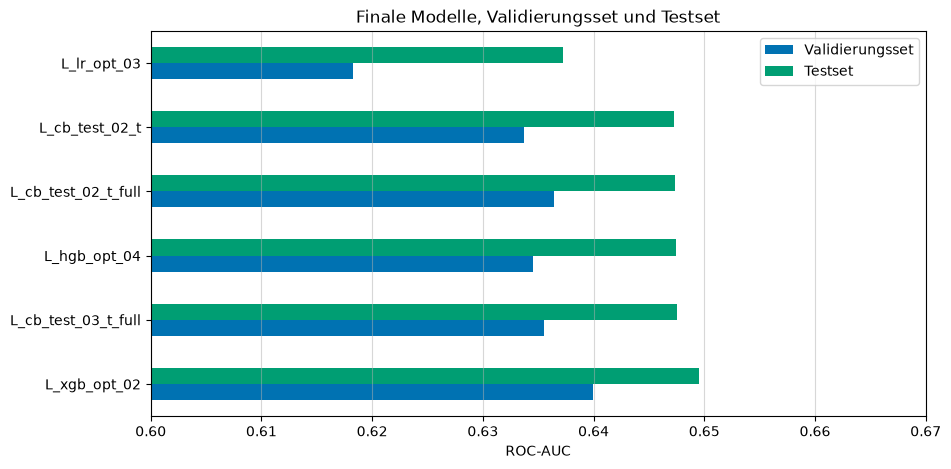

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

(
    df_results
    .set_index("model_idx")[["auc_val", "auc_test"]]
    .rename(columns={
        "auc_val": "Validierungsset", 
        "auc_test": "Testset"
    })
    .plot.barh(
        ax=ax
    )
)

ax.set_xlim(0.60, 0.67)
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("")
ax.set_title("Finale Modelle, Validierungsset und Testset")
ax.legend()
ax.grid(axis="x", alpha=0.5)

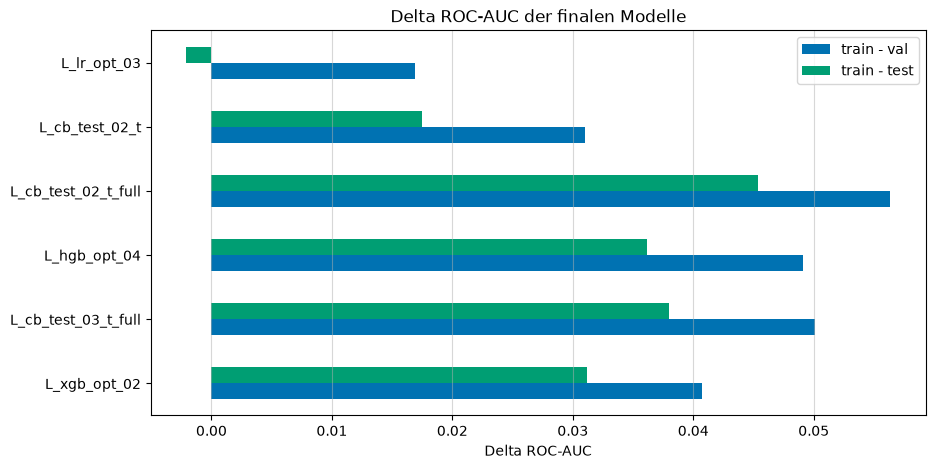

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

(
    df_results
    .set_index("model_idx")[["delta_auc_train_val", "delta_auc_train_test"]]
    .rename(columns={
        "delta_auc_train_val": "train - val", 
        "delta_auc_train_test": "train - test"
    })
    .plot.barh(
        ax=ax
    )
)

ax.set_xlabel("Delta ROC-AUC")
ax.set_ylabel("")
ax.set_title("Delta ROC-AUC der finalen Modelle")
ax.legend()
ax.grid(axis="x", alpha=0.5)

## Ergebnis Überprüfung an Notebook 23

In [37]:
referenz = {
    "L_xgb_opt_02": {"auc_test": 0.649495, "best_iter": 139},
    "L_hgb_opt_04": {"auc_test": 0.647474, "best_iter": 365},
    "L_cb_test_02_t": {"auc_test": 0.647273, "best_iter": 518},
    "L_cb_test_02_t_full": {"auc_test": 0.647385, "best_iter": 558},
    "L_cb_test_03_t_full": {"auc_test": 0.647561, "best_iter": 789},
    "L_lr_opt_03": {"auc_test": 0.637237, "best_iter": 500}
}

In [38]:
check = []

for name, ref in referenz.items():
    row = df_results.loc[df_results["model_idx"] == name].iloc[0]
    check.append({
         "model_idx": name,
        "auc_test_23": ref["auc_test"],
        "auc_test_neu": row["auc_test"],
        "diff_auc": row["auc_test"] - ref["auc_test"],
        "best_iter_23": ref["best_iter"],
        "best_iter_neu": row["best_iter"],
        "identisch": abs(row["auc_test"] - ref["auc_test"]) < 1e-4 and row["best_iter"] == ref["best_iter"]
    })

pd.DataFrame(check)

,model_idx,auc_test_23,auc_test_neu,diff_auc,best_iter_23,best_iter_neu,identisch
0,L_xgb_opt_02,0.649495,0.649495,-4.720969e-07,139,139,True
1,L_hgb_opt_04,0.647474,0.647474,-4.585453e-07,365,365,True
2,L_cb_test_02_t,0.647273,0.647273,1.855940e-07,518,518,True
3,L_cb_test_02_t_full,0.647385,0.647385,-4.064509e-07,558,558,True
4,L_cb_test_03_t_full,0.647561,0.647561,-2.630702e-07,789,789,True
5,L_lr_opt_03,0.637237,0.637237,4.502403e-07,500,500,True


## Predictions

In [40]:
Pred_L_xgb_opt_02 = L_xgb_opt_02.predict_proba(x_test)[:, 1]
Pred_L_hgb_opt_04 = L_hgb_opt_04.predict_proba(x_test)[:, 1]
Pred_L_cb_test_02_t = L_cb_test_02_t.predict_proba(x_test)[:, 1]
Pred_L_cb_test_02_t_full = L_cb_test_02_t_full.predict_proba(x_test)[:, 1]
Pred_L_cb_test_03_t_full = L_cb_test_03_t_full.predict_proba(x_test)[:, 1]
Pred_L_lr_opt_03 = L_lr_opt_03.predict_proba(x_test)[:, 1]

preds_test = pd.DataFrame({
    "Pred_L_xgb_opt_02": L_xgb_opt_02.predict_proba(x_test)[:, 1],
    "Pred_L_hgb_opt_04": L_hgb_opt_04.predict_proba(x_test)[:, 1],
    "Pred_L_cb_test_02_t": L_cb_test_02_t.predict_proba(x_test)[:, 1],
    "Pred_L_cb_test_02_t_full": L_cb_test_02_t_full.predict_proba(x_test)[:, 1],
    "Pred_L_cb_test_03_t_full": L_cb_test_03_t_full.predict_proba(x_test)[:, 1],
    "Pred_L_lr_opt_03": L_lr_opt_03.predict_proba(x_test)[:, 1]
}, index=x_test.index)

## Modelle Korrelation

In [41]:
pred_korr = preds_test.corr(method="spearman").round(3)
pred_korr

,Pred_L_xgb_opt_02,Pred_L_hgb_opt_04,Pred_L_cb_test_02_t,Pred_L_cb_test_02_t_full,Pred_L_cb_test_03_t_full,Pred_L_lr_opt_03
Pred_L_xgb_opt_02,1.000,0.958,0.945,0.951,0.943,0.877
Pred_L_hgb_opt_04,0.958,1.000,0.952,0.958,0.948,0.898
Pred_L_cb_test_02_t,0.945,0.952,1.000,0.965,0.958,0.897
Pred_L_cb_test_02_t_full,0.951,0.958,0.965,1.000,0.956,0.911
Pred_L_cb_test_03_t_full,0.943,0.948,0.958,0.956,1.000,0.884
Pred_L_lr_opt_03,0.877,0.898,0.897,0.911,0.884,1.000


Text(0.5, 1.0, 'Korrelationen der Predictions (Testset)')

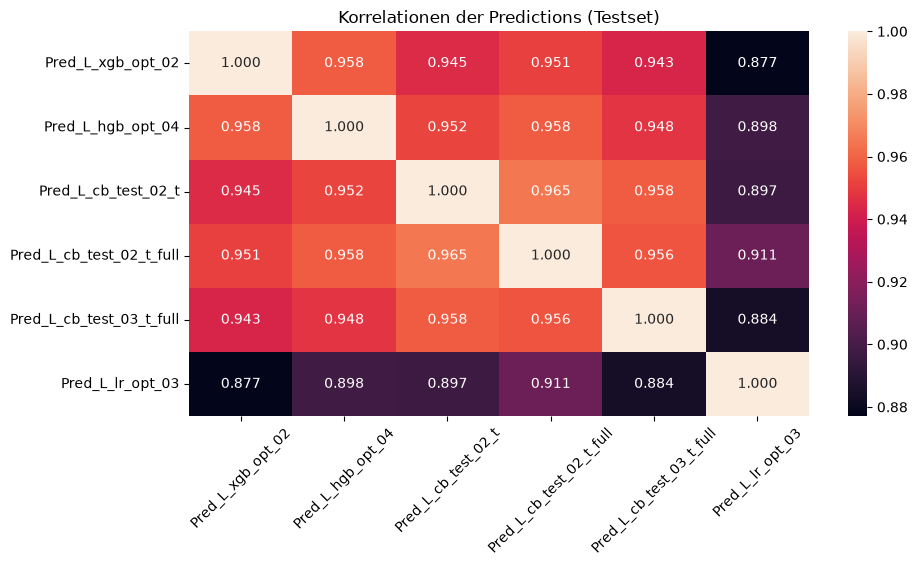

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    pred_korr,
    ax=ax,
    annot=True,
    fmt=".3f"
)
ax.tick_params(axis="x", rotation=45)
ax.set_title("Korrelationen der Predictions (Testset)")

## Notizen
- Ich versuche hier die Modelle nochmal standalone trainierbar zu machen und die Modelle etwas mehr straightforward zu gestalten. Pipelines etc wo es geht um möglichst wenig händische Vorarbeit zu leisten
- Ich hole die Parameter aus der study selber, im get all params ist scheinbar gerundet, den punkt muss ich eventuell noch in den vorangegangenen notebooks ko´rrigieren, oder ein notebook, das einzig und allein optuna studys anschaut
- Ich passe eval_model an, dann kann ich sowohl auc_val als auch auc_test absehen.
- bei hgb hatte ich x_train_hgb[feat_no_cols] verwendet, was wahrscheinlich eine andere struktur bekommt, wenn ein column transformer splaten droppt. hgb arbeitet durch max_features mit Ziehungen, die anhand des random states eventuell anders abfolgen würden, bei andere struktur.
- Ich benutze jetzt doch wieder etwas pipeline statt wie in der VL mak_pipeline, um die abteile besser callen zu können
- ICh checke nochmal gegen ob die ergebnisse hier denen aus 23 entsprechen